In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import mne
import entropy as ent
import neurokit2 as nk
from scipy.signal import welch
from nolds import lyap_r
import antropy as ant
import joblib
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

 # ** NOTICE: all references to control is actually dementia, i need to rename the variables

In [12]:
alz_df = pd.read_pickle("alzeimers.pkl")
control_df = pd.read_pickle("dementia.pkl")

In [13]:
print(alz_df.head())

                                                              Window Avg
Subject Channel Band                                                    
sub-001 Fp1     Delta  [0.08257892642542035, 0.06207167403073861, 0.0...
                Theta  [0.0056116456857143, 0.02276926422235818, 0.01...
                Alpha  [0.0011432203881714235, 0.001169193032401488, ...
                Beta   [0.00019580400803236134, 0.000554631455643691,...
        Fp2     Delta  [0.08389220643958974, 0.06238665599952738, 0.0...


# NEED to do the preprocessing with train and test instead of the combined value

In [16]:
# Get unique subject IDs
alz_subjects = alz_df.index.get_level_values("Subject").unique()
control_subjects = control_df.index.get_level_values("Subject").unique()

# Select the last 3 subjects for testing
test_alz_subjects = alz_subjects[-3:]  # Last 3 subjects
test_control_subjects = control_subjects[-3:]  # Last 3 subjects

# Select training subjects (all except the last 3)
train_alz_subjects = alz_subjects[:-3]
train_control_subjects = control_subjects[:-3]

# Split DataFrames
alz_train_df = alz_df.loc[train_alz_subjects]
alz_test_df = alz_df.loc[test_alz_subjects]

control_train_df = control_df.loc[train_control_subjects]
control_test_df = control_df.loc[test_control_subjects]

In [17]:
#combining the data so that there is no differentiation between the subjects
alz_train_df_combined = alz_train_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()
alz_test_df_combined = alz_test_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()

control_train_df_combined = control_train_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()
control_test_df_combined = control_test_df.groupby(["Channel", "Band"])["Window Avg"].sum().to_frame()

In [18]:
print(alz_train_df_combined.head())

                                                      Window Avg
Channel Band                                                    
C3      Alpha  [0.0015840474593109583, 0.001929353911668195, ...
        Beta   [0.00032858350615259387, 0.0004325061241946445...
        Delta  [0.08289602096613104, 0.08146479821965336, 0.0...
        Theta  [0.004282640877382271, 0.004781636828107, 0.00...
C4      Alpha  [0.0012796666090331263, 0.0012960394954895005,...


In [19]:
import numpy as np


# ** should we do this for both of them seperately, or do them together ? 
# Function to normalize train & test data per channel and band
def normalize_band(train_df, test_df):
    # Make copies to avoid modifying original data
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Iterate through each unique (Channel, Band) pair in training set
    for (channel, band) in train_df.index.unique():
        try:
            # print(f"Current ({channel}, {band}) ")
            
            # Get the "Window Avg" list for the current channel-band pair
            train_values = np.array(train_df.loc[(channel, band), "Window Avg"])
            test_values = np.array(test_df.loc[(channel, band), "Window Avg"])

            # Compute mean and standard deviation from training set
            mean_train = np.mean(train_values)
            std_train = np.std(train_values)

            # Check data distribution
            '''
            above_mean = np.sum(train_values > mean_train) / len(train_values)
            within_1std = np.sum((train_values > mean_train - std_train) & (train_values < mean_train + std_train)) / len(train_values)
            within_2std = np.sum((train_values > mean_train - 2*std_train) & (train_values < mean_train + 2*std_train)) / len(train_values)
            within_3std = np.sum((train_values > mean_train - 3*std_train) & (train_values < mean_train + 3*std_train)) / len(train_values)

            print(f" % of values ABOVE mean: {above_mean*100:.2f}%")
            print(f" % within 1 std: {within_1std*100:.2f}%")
            print(f" % within 2 std: {within_2std*100:.2f}%")
            print(f" % within 3 std: {within_3std*100:.2f}%\n") 
            '''
            
            # Ensure standard deviation is not zero (to prevent division by zero)
            if std_train == 0:
                print("STD train is 0")
                std_train = 1  # Avoid division error, keeps data unchanged


            # Normalize training data using training mean & std
            try:
                train_df.loc[(channel, band), "Window Avg"] = [(x - mean_train) / std_train for x in train_values]
            except:
                pass
            # Normalize test data using training mean & std
            try:
                test_df.loc[(channel, band), "Window Avg"] = [(x - mean_train) / std_train for x in test_values]
            except:
                pass
 
        except Exception as e:
            print(f" Error processing ({channel}, {band}): {e}")
    
    return train_df, test_df

# Apply function to Alzheimer's group
alz_train_scaled, alz_test_scaled = normalize_band(alz_train_df_combined, alz_test_df_combined)

# Apply function to Control group
control_train_scaled, control_test_scaled = normalize_band(control_train_df_combined, control_test_df_combined)

# Print first few rows
print("Alz Train Sclaed")
print(alz_train_scaled.head())
print("Alz Test Sclaed")
print(alz_test_scaled.head())
print("Control Training Sclaed")
print(control_train_scaled.head())
print("Control Test Sclaed")
print(control_test_scaled.head())


Alz Train Sclaed
                                                      Window Avg
Channel Band                                                    
C3      Alpha  [-0.028380469596105816, 0.17670784418076405, -...
        Beta   [-0.1736496868272443, 0.04432798476089755, -0....
        Delta  [0.21016328933155926, 0.0008157173261267524, 0...
        Theta  [-0.24421261001928626, -0.10831794551605334, -...
C4      Alpha  [-0.21038420497404048, -0.2006687350757205, -0...
Alz Test Sclaed
                                                      Window Avg
Channel Band                                                    
C3      Alpha  [-0.1197637308552774, 0.09066435583103213, -0....
        Beta   [-0.31580405309032666, -0.0685475137807336, -0...
        Delta  [0.1893556174417506, 0.20225008713214998, 0.49...
        Theta  [-0.08374115386577594, -0.34670136495223813, -...
C4      Alpha  [-0.4449321835424517, 0.10777901903266122, -0....
Control Training Sclaed
                                 

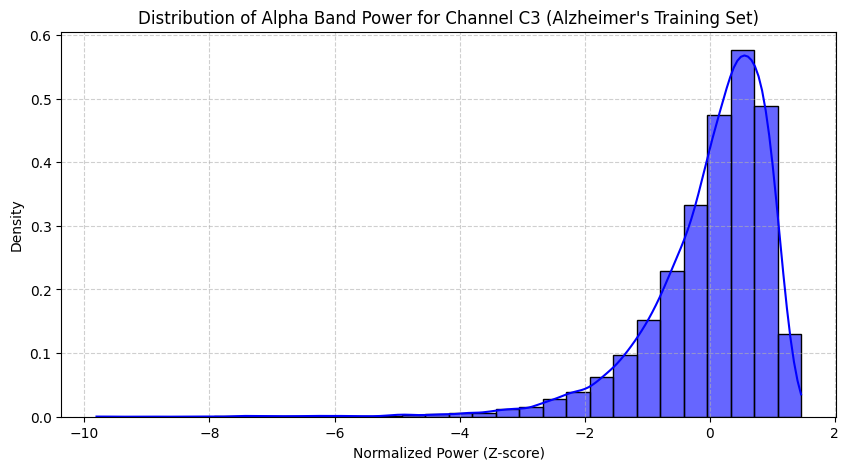

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract only the "Alpha" band for channel "C3"
alpha_c3_data = alz_train_scaled.loc[("Fp1", "Delta"), "Window Avg"]

# Ensure data is in list format
if isinstance(alpha_c3_data, list) or isinstance(alpha_c3_data, np.ndarray):
    plt.figure(figsize=(10, 5))

    # Plot histogram with density estimation (Kernel Density Estimation - KDE)
    sns.histplot(alpha_c3_data, bins=30, kde=True, color="blue", stat="density", alpha=0.6)

    plt.ylabel("Density")
    plt.xlabel("Normalized Power (Z-score)")
    plt.title("Distribution of Alpha Band Power for Channel C3 (Alzheimer's Training Set)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
else:
    print("⚠️ The extracted data is not in list format. Check if 'Window Avg' contains lists of values.")


# DOING PCA HERE ... 

In [21]:
import numpy as np
import pandas as pd

# Flatten multi-index and create new column names
df_reshaped = alz_train_scaled["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
# df_reshaped = control_train_scaled["Window Avg"].apply(pd.Series)  # Expands lists into separate columns
df_reshaped.index = df_reshaped.index.map(lambda x: f"{x[0]}_{x[1]}")  # Convert (Channel, Band) tuple into string
df_reshaped = df_reshaped.T  # Transpose so that rows = epochs and columns = features

# Convert to NumPy array (for PCA)
X_pca = df_reshaped.to_numpy()

# Print structure
print("PCA Input Shape:", X_pca.shape)  # (n_samples, n_features)
print("Feature Names:", df_reshaped.columns.tolist())  # Check feature names

PCA Input Shape: (17830, 76)
Feature Names: ['C3_Alpha', 'C3_Beta', 'C3_Delta', 'C3_Theta', 'C4_Alpha', 'C4_Beta', 'C4_Delta', 'C4_Theta', 'Cz_Alpha', 'Cz_Beta', 'Cz_Delta', 'Cz_Theta', 'F3_Alpha', 'F3_Beta', 'F3_Delta', 'F3_Theta', 'F4_Alpha', 'F4_Beta', 'F4_Delta', 'F4_Theta', 'F7_Alpha', 'F7_Beta', 'F7_Delta', 'F7_Theta', 'F8_Alpha', 'F8_Beta', 'F8_Delta', 'F8_Theta', 'Fp1_Alpha', 'Fp1_Beta', 'Fp1_Delta', 'Fp1_Theta', 'Fp2_Alpha', 'Fp2_Beta', 'Fp2_Delta', 'Fp2_Theta', 'Fz_Alpha', 'Fz_Beta', 'Fz_Delta', 'Fz_Theta', 'O1_Alpha', 'O1_Beta', 'O1_Delta', 'O1_Theta', 'O2_Alpha', 'O2_Beta', 'O2_Delta', 'O2_Theta', 'P3_Alpha', 'P3_Beta', 'P3_Delta', 'P3_Theta', 'P4_Alpha', 'P4_Beta', 'P4_Delta', 'P4_Theta', 'Pz_Alpha', 'Pz_Beta', 'Pz_Delta', 'Pz_Theta', 'T3_Alpha', 'T3_Beta', 'T3_Delta', 'T3_Theta', 'T4_Alpha', 'T4_Beta', 'T4_Delta', 'T4_Theta', 'T5_Alpha', 'T5_Beta', 'T5_Delta', 'T5_Theta', 'T6_Alpha', 'T6_Beta', 'T6_Delta', 'T6_Theta']


In [22]:
print("NaNs in X_train:", np.isnan(X_pca).sum())

NaNs in X_train: 0


In [23]:

# Apply PCA (reduce to 15 components for example)
pca = PCA(n_components=15)
X_pca_transformed = pca.fit_transform(X_pca)

# Print PCA results
print("PCA Output Shape:", X_pca_transformed.shape)  # (17830, 10)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

PCA Output Shape: (17830, 15)
Explained Variance Ratio: [0.58326401 0.10737446 0.08955702 0.03637641 0.02190768 0.01653056
 0.01563926 0.01193116 0.01003805 0.00953225 0.00691969 0.00686231
 0.00650994 0.00600233 0.00529005]


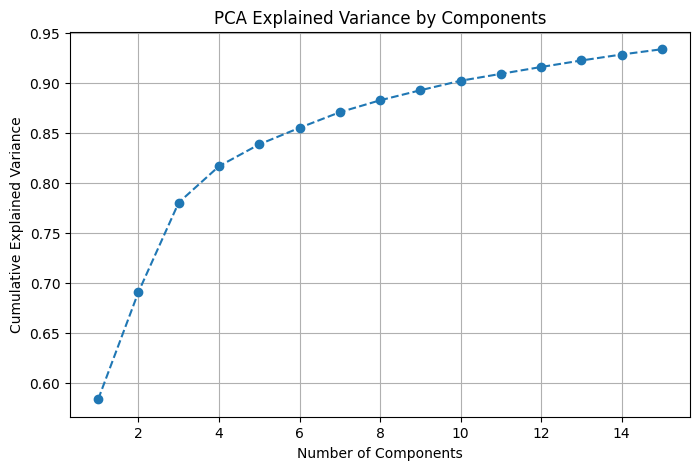

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 16), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance by Components')
plt.grid()
plt.show()

In [25]:
# Doing ML portion now 

In [26]:
def multi_index(data_scaled):
    """
    data_scaled is a DataFrame where:
      - The index is a MultiIndex of (Channel, Band)
      - 'Window Avg' column has the list of average values for each epoch
    This function expands those average values into separate columns.
    Then transposes, so rows become epochs and columns become features.
    """
    df_reshaped = data_scaled["Window Avg"].apply(pd.Series)  # Expand lists into columns
    # Flatten multi-index: if the index is (Channel, Band), turn it into "Channel_Band"
    df_reshaped.index = df_reshaped.index.map(lambda x: f"{x[0]}_{x[1]}")
    df_reshaped = df_reshaped.T  # transpose so rows=epochs, columns=features
    return df_reshaped

X_alz_train = multi_index(alz_train_scaled)
X_alz_test = multi_index(alz_test_scaled)
X_control_train = multi_index(control_train_scaled)
X_control_test = multi_index(control_test_scaled)


In [27]:
y_alz_train = np.ones(X_alz_train.shape[0], dtype=int)
y_alz_test = np.ones(X_alz_test.shape[0], dtype=int)
y_control_train = np.zeros(X_control_train.shape[0], dtype=int)
y_control_test = np.zeros(X_control_test.shape[0], dtype=int)


In [28]:
# Combine features
X_train = pd.concat([X_alz_train, X_control_train], ignore_index=True)
X_test  = pd.concat([X_alz_test,  X_control_test ], ignore_index=True)

# Combine labels
y_train = np.concatenate([y_alz_train, y_control_train])
y_test  = np.concatenate([y_alz_test,  y_control_test])


In [29]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (27595, 76)
y_train shape: (27595,)
X_test shape: (3083, 76)
y_test shape: (3083,)


# PCA

In [30]:
pca = PCA(n_components=10)
X_train_pca_transformed = pca.fit_transform(X_train)  # shape (N_train, 10)
X_test_pca_transformed  = pca.transform(X_test)       # shape (N_test, 10)

# ML and analysis

In [31]:
knn = KNeighborsClassifier(n_neighbors=150)
knn.fit(X_train_pca_transformed, y_train)

y_pred = knn.predict(X_test_pca_transformed)
acc = accuracy_score(y_test, y_pred)


In [32]:
report = classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1'])

# Print the classification report
print(f"KNN accuracy: {acc:.4f}")
print(report)

KNN accuracy: 0.6101
              precision    recall  f1-score   support

     Class 0       0.74      0.19      0.30      1367
     Class 1       0.59      0.95      0.73      1716

    accuracy                           0.61      3083
   macro avg       0.66      0.57      0.52      3083
weighted avg       0.66      0.61      0.54      3083



In [33]:
svm = SVC(kernel='rbf', C=1.0)  # You can change the kernel to 'linear', 'poly', or 'sigmoid'

# Train the SVM model
svm.fit(X_train_pca_transformed, y_train)

# Predict using the trained SVM model
y_pred_svm = svm.predict(X_test_pca_transformed)

# Compute accuracy
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_svm = classification_report(y_test, y_pred_svm, target_names=['Class 0', 'Class 1'])
print(report_svm)

SVM Accuracy: 0.6646
              precision    recall  f1-score   support

     Class 0       0.84      0.30      0.44      1367
     Class 1       0.63      0.95      0.76      1716

    accuracy                           0.66      3083
   macro avg       0.74      0.63      0.60      3083
weighted avg       0.72      0.66      0.62      3083



In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators

# Train the Random Forest model
rf.fit(X_train_pca_transformed, y_train)

# Predict using the trained Random Forest model
y_pred_rf = rf.predict(X_test_pca_transformed)

# Compute accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

# Generate and print classification report (Precision, Recall, F1 Score)
report_rf = classification_report(y_test, y_pred_rf, target_names=['Class 0', 'Class 1'])
print(report_rf)

Random Forest Accuracy: 0.6007
              precision    recall  f1-score   support

     Class 0       0.62      0.26      0.37      1367
     Class 1       0.60      0.87      0.71      1716

    accuracy                           0.60      3083
   macro avg       0.61      0.57      0.54      3083
weighted avg       0.61      0.60      0.56      3083



In [35]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
gbc.fit(X_train_pca_transformed, y_train)

# Make predictions
y_pred = gbc.predict(X_test_pca_transformed)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Model Accuracy: {accuracy:.4f}%")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gradient Boosting Model Accuracy: 0.6186%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.22      0.34      1367
           1       0.60      0.94      0.73      1716

    accuracy                           0.62      3083
   macro avg       0.67      0.58      0.54      3083
weighted avg       0.66      0.62      0.56      3083

